In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [ ]:
# import data

conn = sqlite3.connect("customer_churn.db")

sql_query = """
            select name from sqlite_master
            where type='table';
"""
tables = pd.read_sql(sql_query, conn)

if tables.empty:
    conn.close()
    raise FileNotFoundError(
        "customer_churn.db contains no tables. Add the churn database beside this notebook "
        "before running the analysis."
    )

for table_name in tables["name"]:
    df = pd.read_sql(f"select * from {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")
conn.close()


Data Cleaning

In [17]:
df_db_customer.head()

NameError: name 'df_db_customer' is not defined

In [ ]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [ ]:
#a.rename column-name
#b. drop column-interests,pincode 
#c.change datatype-dob
#d.data standardization-gender
#e.fix missing value-country

In [ ]:
#a.rename column-name
df_db_customer.rename(columns={"name": "customer_name"},inplace=True)

In [ ]:
df_db_customer

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None
5,0013-MHZWF,durga,None,Delhi,Women,1988-12-10 00:00:00,None,None
6,0013-SMEOE,mina,India,Meghalaya,Female,1976-09-21 00:00:00,None,None
7,0014-BMAQU,madan,India,Rajasthan,Male,1999-03-14 00:00:00,None,None
8,0015-UOCOJ,maya,None,Kathmandu,Women,1985-07-07 00:00:00,None,None
9,0016-QLJIS,arjun,Nepal,Kathmandu,Male,1993-10-29 00:00:00,None,None


In [ ]:
#b.drop column
df_db_customer.drop(columns=['interests','pincode'],axis=1,inplace=True)

In [ ]:
#c.change datatype-dob
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

In [ ]:
#d.data standardization-gender
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

In [ ]:
#e.fix missing value-country

In [ ]:
df_db_customer[df_db_customer['country'].isnull()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [ ]:

df_db_customer['country'].fillna('nahi pata')

0         India
1         India
2         India
3         India
4         India
5     nahi pata
6         India
7         India
8     nahi pata
9         Nepal
10        India
11        India
12    nahi pata
13        India
14        India
15        India
16        India
17        India
18        India
19        India
20        India
Name: country, dtype: object

In [ ]:
#country and state unique pair
state_country_mapping=df_db_customer.set_index('state')['country'].to_dict()
df_db_customer['country']=df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))


In [ ]:
df_db_customer[df_db_customer['country'].isnull()]

,customerid,customer_name,country,state,gender,dob


In [ ]:
df_db_subscription

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,None,None,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,None,None,22.99,1840,5
8,0015-UOCOJ,2023-07-22,Organic,2024-07-22,Standard,Monthly,None,None,13.99,240,34
9,0016-QLJIS,2022-04-03,Organic,2025-04-03,Basic,Annual,None,None,6.99,335,41


In [ ]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     object 
 1   subscription_start_date  21 non-null     object 
 2   subscription_type        21 non-null     object 
 3   renewal_date             21 non-null     object 
 4   plan_type                21 non-null     object 
 5   contract_type            21 non-null     object 
 6   cancellation_date        6 non-null      object 
 7   cancellation_reason      6 non-null      object 
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 1.9+ KB


In [ ]:
date_col=['subscription_start_date','renewal_date','cancellation_date']

df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


In [ ]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [ ]:
df_db_support.drop(columns={"col_1","comment"},inplace=True)

In [ ]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [ ]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


3.Feature Engineeering

In [ ]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [ ]:
#create new column using existing col

df_db_subscription['Churn Flag']= np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [ ]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,Churn Flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [ ]:
#first fix support table duplicates then merge
df=df_db_subscription.merge(df_db_customer,on='customerid',how='left').merge(df_db_support,on='customerid',how='left')

In [ ]:
df.shape

(23, 20)

In [ ]:
df_db_subscription['customerid'].nunique()

21

In [ ]:
df_db_customer['customerid'].nunique()

21

In [ ]:
df_db_support['customerid'].nunique()

7

In [ ]:
df_db_support['customerid'].size

9

In [ ]:
df_db_support['complaint_count']=df_db_support.groupby('customerid')['customerid'].transform('count')

In [ ]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
0,0003-MKNFE,2024-08-28,N,60,2
1,0003-MKNFE,2024-08-28,Y,10,2
2,0013-EXCHZ,2024-01-20,Y,20,1
3,0013-MHZWF,2025-03-18,N,90,1
4,0013-SMEOE,2024-11-01,N,30,1
5,0017-IUDMW,2024-04-10,Y,25,1
6,0019-EFAEP,2024-09-27,Y,30,1
7,0022-TCJCI,2024-09-13,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2


In [ ]:
df_db_support=df_db_support.sort_values('complaint_date').drop_duplicates('customerid',keep='last')

In [ ]:
df_db_support['customerid'].size

7

In [ ]:
#merge df
df=df_db_subscription.merge(df_db_customer,on='customerid',how='left').merge(df_db_support,on='customerid',how='left')

In [ ]:
df.shape

(21, 21)

4.Data analysis

In [ ]:

#1 churn rate
churn_rate=df['Churn Flag'].mean()*100
print("churn rate =",round(churn_rate,2),"%")

churn rate = 28.57 %


In [ ]:
#retention rate
retention_rate=100-churn_rate
print("retention rate =",round(retention_rate,2),"%")

retention rate = 71.43 %


In [ ]:
#3 churn by plan type

churn_by_plan=(df.groupby('plan_type')['Churn Flag'].mean().mul(100).round(2).reset_index(name='churn rate percentage'))
print(churn_by_plan)

  plan_type  churn rate percentage
0     Basic                  60.00
1   Premium                  14.29
2  Standard                  22.22


In [ ]:
 df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,Churn Flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0,2.0
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN,NaN
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN,NaN
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,1,mira,India,Delhi,Female,1990-05-05,2024-01-20,Y,20.0,1.0


In [ ]:
df.groupby('state').agg(
    total_revenue=('monthly_charges','sum'),
    total_users=('customerid','count')
).reset_index()

,state,total_revenue,total_users
0,Delhi,52.96,4
1,Karnataka,20.98,2
2,Kathmandu,20.98,2
3,Maharashtra,50.97,3
4,Meghalaya,42.97,3
5,Nagaland,22.99,1
6,Rajasthan,36.98,2
7,Telangana,30.98,2
8,Uttar Pradesh,115.98,2


In [ ]:
df.groupby('subscription_type').agg(
    total_revenue=('monthly_charges','sum'),
    total_users=('customerid','count')
).reset_index()

,subscription_type,total_revenue,total_users
0,Organic,145.91,9
1,Paid,174.94,6
2,Refferal,74.94,6


In [ ]:
#Average revenue per user
arpu=df['monthly_charges'].mean()
print('ARPU=',round(arpu,2))

ARPU= 18.85


In [ ]:
#avg customer tenure
#count of days user has used our servicea : cancellation date else current date

today=pd.Timestamp.today()

df['tenure_days']=np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today-df['subscription_start_date']).dt.days
)



avg_tenure_days=df['tenure_days'].mean().round(0)
print("Avg tenure (days)=",avg_tenure_days)

Avg tenure (days)= 1547.0


In [ ]:
#revenue at risk -revenue loss by churn users

revenue_at_risk=df.loc[df['Churn Flag']==1,'monthly_charges'].sum()
print("Revenue at risk (Rs K)=",revenue_at_risk)

Revenue at risk (Rs K)= 73.94


In [ ]:
#Escalation rate
escalation_rate=(df['escalations']=='Y').mean()*100
print("Escalation rate =",round(escalation_rate,2),"%")

Escalation rate = 19.05 %


In [ ]:
#avg complaint per user
avg_complaints=df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg compliants per user= ",round(avg_complaints,2))

Avg compliants per user=  0.43


In [ ]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'Churn Flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='object')

In [ ]:
# Escalation vs churn correlation
corr_df = df[['escalations', 'Churn Flag']].dropna().copy()
corr_df['escalations'] = corr_df['escalations'].map({'Y': 1, 'N': 0})
corr_df = corr_df.dropna()

correlation = corr_df['escalations'].corr(corr_df['Churn Flag'])

print("Correlation between escalation vs churn is =", round(correlation, 2))

ValueError: could not convert string to float: 'Y'

In [ ]:
#churn risk

condition=[
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]
choice=['low','med','high']

df['churn risk']=np.select(condition,choice,default='unknown')

In [ ]:
df[['churn_score','churn risk']].head()

Data visualization using matplotlib

In [ ]:
df_visual=df.copy()

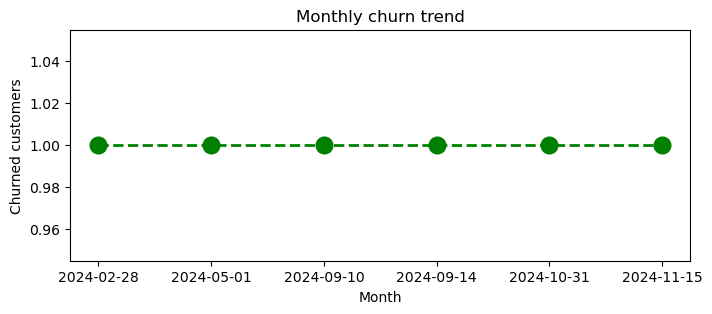

In [ ]:
#Monthly churn trend
df_visual['cancellation_month']=df_visual['cancellation_date']
churn_trend =df_visual[df_visual['Churn Flag']==1].groupby('cancellation_month').size()


plt.figure(figsize=(8,3))
plt.title("Monthly churn trend")
plt.xlabel("Month")
plt.ylabel("Churned customers")
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green', marker='o', linestyle='dashed',linewidth=2, markersize=12)
plt.show()


In [ ]:
# churn by plan
churn_plan = df_visual.groupby('plan_type')['Churn Flag'].mean()
plt.figure(figsize=(7,4))
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.bar(churn_plan.index, churn_plan.values, color=colors)
plt.show()

NameError: name 'df_visual' is not defined

In [ ]:
churn_plan = df_visual.groupby('state')['Churn Flag'].mean()
plt.figure(figsize=(12,4))
colors=plt.cm.Set2(np.linspace(0,1,len(churn_plan)))
plt.bar(churn_plan.index,churn_plan.values,color=colors)
plt.show()


NameError: name 'df_visual' is not defined

Visualization using seaborn

In [ ]:
df_visual.columns

NameError: name 'df_visual' is not defined

In [ ]:
# Encode categorical columns using their defined order.
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'Churn Flag', 'churn risk', 'escalations']].copy()
ordered_mapping = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn risk': ['low', 'med', 'high']
}
for column, order in ordered_mapping.items():
    df_encoded[column] = pd.Categorical(
        df_encoded[column], categories=order, ordered=True
    ).codes
df_encoded['escalations'] = df_encoded['escalations'].map({'Y': 1, 'N': 0})

NameError: name 'df_visual' is not defined

In [ ]:
# Encode categorical columns using their defined order.
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'Churn Flag', 'churn risk', 'escalations']].copy()
ordered_mapping = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type': ['Monthly', 'Annual'],
    'churn risk': ['low', 'med', 'high']
}
for column, order in ordered_mapping.items():
    df_encoded[column] = pd.Categorical(
        df_encoded[column], categories=order, ordered=True
    ).codes
df_encoded['escalations'] = df_encoded['escalations'].map({'Y': 1, 'N': 0})

NameError: name 'df_visual' is not defined

In [ ]:
#heatmap
sns.heatmap(df_encoded.corr(),annot=True)

NameError: name 'df_encoded' is not defined

In [ ]:
#pairplot
sns.pairplot(df_encoded)


In [ ]:
#catplot
sns.catplot(data=df_visual,
            x='plan_type',
            y='monthly_charges',
            hue='gender',
            col='churn risk'
           )

Pivot table

In [ ]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'Churn Flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'cancellation_month'],
      dtype='object')

In [ ]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','Churn Flag'],
    aggfunc={
    'monthly_charges':'sum',
    'customerid':'nunique',
    'Churn Flag':'mean'
}
).reset_index()

,plan_type,Churn Flag,customerid,monthly_charges
0,Basic,0.600000,5,52.95
1,Premium,0.142857,7,218.93
2,Standard,0.222222,9,123.91


Working with Sql in python

In [ ]:
# create db in sql
conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute("CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)")

# commit and save
conn.commit()

print("Cretaed Table successfully!")

Cretaed Table successfully!


In [ ]:
# insert data

cursor = conn.cursor()

# write sql query to insert records in sql table
cursor.execute(
    """
        INSERT INTO users VALUES
            ('Madhav', 'India', 5000),
            ('Rishabh', 'Germany', 2500),
            ('Vishakha', 'India', 3500)
    """
)

# commit and save
conn.commit()

print("Data Inserted successfully!")

Data Inserted successfully!


In [ ]:
# check inserted data in table
conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Madhav,India,5000
1,Rishabh,Germany,2500
2,Vishakha,India,3500


In [ ]:
# aggregation
query = """
        SELECT country, SUM(budget) as total_budget
        FROM users
        GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,8500


In [ ]:
# always close the conn with db once the task is over
conn.close()